In [27]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [29]:
df1 = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/Dissertation/dft-road-casualty-statistics-collision-2024.csv")
print(df1.shape)

(100927, 44)


/tmp/ipykernel_3937/3231258826.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/Dissertation/dft-road-casualty-statistics-collision-2024.csv")


In [30]:
df1.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202417M119024,2024,17M119024,450057,519938,-1.22722,54.57219,17,3,2,...,-1,0,1,3,2,E01035190,3,1,0.000000,1.000000
1,202417S312124,2024,17S312124,445858,516830,-1.29265,54.54466,17,3,1,...,-1,0,1,3,2,E01012239,3,1,0.000000,1.000000
2,2024070110901,2024,070110901,364765,390979,-2.53157,53.41443,7,3,2,...,0,0,2,2,2,E01012459,-1,0,0.014743,0.985257
3,2024041446676,2024,041446676,365989,419804,-2.51630,53.67359,4,2,1,...,-1,0,2,1,2,E01012628,6,1,1.000000,0.000000
4,2024041478641,2024,041478641,366864,430071,-2.50416,53.76592,4,2,2,...,-1,0,1,1,2,E01012581,7,1,1.000000,0.000000


In [31]:
collision_features = [
    'collision_ref_no', 'collision_severity', 'number_of_vehicles',
    'date', 'day_of_week', 'time', 'first_road_class', 'road_type',
    'junction_detail', 'light_conditions', 'weather_conditions',
    'speed_limit', 'road_surface_conditions', 'urban_or_rural_area'
]

In [32]:
df2 = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/Dissertation/dft-road-casualty-statistics-vehicle-2024.csv")
print(df2.shape)

(183514, 32)


/tmp/ipykernel_3937/3840957520.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/Dissertation/dft-road-casualty-statistics-vehicle-2024.csv")


In [33]:
df2.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2024471526976,2024,471526976,2,4,0,-1,19,4,8,...,23,5,234,1,16,MAKE AND MODEL REDACTED,8,E01020954,0,1
1,2024471493223,2024,471493223,2,9,0,-1,2,0,0,...,-1,-1,2198,1,15,MAKE AND MODEL REDACTED,-1,-1,0,-1
2,2024010504128,2024,010504128,2,9,0,2,2,0,0,...,-1,-1,2198,1,18,MAKE AND MODEL REDACTED,-1,-1,0,-1
3,2024302400896,2024,302400896,2,9,0,18,19,1,4,...,56,9,6496,1,0,MAKE AND MODEL REDACTED,5,E01019782,0,2
4,2024631472488,2024,631472488,2,90,0,-1,19,7,3,...,55,8,2184,2,0,MAKE AND MODEL REDACTED,7,W01000623,0,4


In [34]:
vehicle_features = [
    'collision_ref_no', 'vehicle_reference', 'vehicle_type', 'vehicle_manoeuvre',
    'skidding_and_overturning', 'hit_object_in_carriageway',
    'hit_object_off_carriageway'
]

In [37]:
df3 = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/Dissertation/dft-road-casualty-statistics-casualty-2024.csv")
print(df3.shape)

(128272, 23)


In [38]:
df3.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2024991534042,2024,991534042,1,1,3,2,39,7,3,...,0,-1,0,-1,-1,3,1,0.00000,1.00000,-1
1,2024430342145,2024,430342145,2,1,1,2,25,5,3,...,0,0,1,4,E01028532,-1,0,0.02417,0.97583,1
2,2024471442093,2024,471442093,2,1,1,1,49,8,3,...,0,0,1,8,E01031491,3,1,0.00000,1.00000,1
3,2024101511084,2024,101511084,1,1,1,2,39,7,3,...,0,0,9,1,E01008859,3,1,0.00000,1.00000,1
4,2024161531062,2024,161531062,1,1,1,1,59,9,3,...,0,0,1,5,E01012902,3,1,0.00000,1.00000,1


In [39]:
casualty_features = [
    'collision_ref_no', 'vehicle_reference', 'sex_of_casualty', 'age_of_casualty'
]

In [40]:
df_collisions_filtered = df1[collision_features]
df_vehicles_filtered = df2[vehicle_features]
df_casualties_filtered = df3[casualty_features]

###**MERGE**

In [41]:
casualty_vehicle_df = df_casualties_filtered.merge(
    df_vehicles_filtered,
    on=['collision_ref_no', 'vehicle_reference'],
    how='inner'
)

In [46]:
merged_df = casualty_vehicle_df.merge(
    df_collisions_filtered,
    on='collision_ref_no',
    how='inner'
)

In [47]:
merged_df = merged_df.drop(columns=['vehicle_reference', 'collision_ref_no'])

In [48]:
print("Merged shape:", merged_df.shape)

Merged shape: (63340, 20)


In [49]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63340 entries, 0 to 63339
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   sex_of_casualty             63340 non-null  int64 
 1   age_of_casualty             63340 non-null  int64 
 2   vehicle_type                63340 non-null  int64 
 3   vehicle_manoeuvre           63340 non-null  int64 
 4   skidding_and_overturning    63340 non-null  int64 
 5   hit_object_in_carriageway   63340 non-null  int64 
 6   hit_object_off_carriageway  63340 non-null  int64 
 7   collision_severity          63340 non-null  int64 
 8   number_of_vehicles          63340 non-null  int64 
 9   date                        63340 non-null  object
 10  day_of_week                 63340 non-null  int64 
 11  time                        63340 non-null  object
 12  first_road_class            63340 non-null  int64 
 13  road_type                   63340 non-null  in

###**CHECK FOR DUPLICATE ROWS**

In [50]:
duplicate_count = merged_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
merged_df = merged_df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", merged_df.shape)

Duplicate rows: 776
Shape after dropping duplicates: (62564, 20)


###**CHECK FOR MISSING VALUES**

In [51]:
listed_df = merged_df.replace({-1: np.nan, '-1': np.nan})

In [52]:
print("--- Missing Values---")
print(listed_df.isnull().sum())

--- Missing Values---
sex_of_casualty                349
age_of_casualty               1063
vehicle_type                   802
vehicle_manoeuvre              971
skidding_and_overturning       864
hit_object_in_carriageway      849
hit_object_off_carriageway     129
collision_severity               0
number_of_vehicles               0
date                             0
day_of_week                      0
time                             0
first_road_class                 0
road_type                        0
junction_detail               3170
light_conditions                 0
weather_conditions               0
speed_limit                      2
road_surface_conditions        385
urban_or_rural_area              0
dtype: int64


####**CORRECT DATA TYPES**

In [53]:
listed_df['time'] = pd.to_datetime(listed_df['time'], format='%H:%M', errors='coerce')
listed_df['date'] = pd.to_datetime(listed_df['date'], format='%d/%m/%Y', errors='coerce')

####**REMOVE UNKNOWN VALUES**

In [54]:
print("Rows with junction_detail == 19:", (listed_df['junction_detail'] == 19).sum())
print("Rows with sex_of_casualty == 9:", (listed_df['sex_of_casualty'] == 9).sum())

valid_mask = (listed_df['junction_detail'] != 19) & (listed_df['sex_of_casualty'] != 9)
listed_df = listed_df[valid_mask].reset_index(drop=True)

Rows with junction_detail == 19: 3694
Rows with sex_of_casualty == 9: 21


In [55]:
print("Shape after removing unknown rows:", listed_df.shape)

Shape after removing unknown rows: (58849, 20)


####**DEFINE X / y**

In [56]:
y = listed_df['collision_severity']
X = listed_df.drop(columns=['collision_severity'])

####**TRAIN-TEST SPLIT**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [58]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (41194, 19), Test shape: (17655, 19)


####**FEATURE ENGINEERING**

In [59]:
def assign_time_period(hour):
    if pd.isna(hour):
        return np.nan
    elif 7 <= hour <= 9:
        return 1  # Morning Rush
    elif 10 <= hour <= 15:
        return 2  # Afternoon
    elif 16 <= hour <= 18:
        return 3  # Evening Rush
    elif 19 <= hour <= 23:
        return 4  # Evening
    else:
        return 5  # Night/Early

def engineer_features(df):
    df = df.copy()

    # Time period
    df['collision_hour'] = df['time'].dt.hour
    df['time_period'] = df['collision_hour'].apply(assign_time_period)
    df = df.drop(columns=['collision_hour', 'time'])

    # Month from date
    df['month'] = df['date'].dt.month
    df = df.drop(columns=['date'])

    # Age group from age of casualty
    bins = [0, 17, 25, 44, 64, 120]
    labels = [1, 2, 3, 4, 5]
    df['age_group'] = pd.cut(df['age_of_casualty'], bins=bins, labels=labels, include_lowest=True)
    df = df.drop(columns=['age_of_casualty'])

    return df

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

In [60]:
print("\n--- Missing values in X_train---")
print(X_train.isnull().sum())
print("\n--- Missing values in X_test---")
print(X_test.isnull().sum())


--- Missing values in X_train---
sex_of_casualty                232
vehicle_type                   535
vehicle_manoeuvre              624
skidding_and_overturning       541
hit_object_in_carriageway      523
hit_object_off_carriageway      65
number_of_vehicles               0
day_of_week                      0
first_road_class                 0
road_type                        0
junction_detail               2196
light_conditions                 0
weather_conditions               0
speed_limit                      1
road_surface_conditions        249
urban_or_rural_area              0
time_period                      0
month                            0
age_group                      690
dtype: int64

--- Missing values in X_test---
sex_of_casualty               104
vehicle_type                  228
vehicle_manoeuvre             244
skidding_and_overturning      220
hit_object_in_carriageway     223
hit_object_off_carriageway     41
number_of_vehicles              0
day_of_week      

####**IMPUTATION**

In [61]:
mode_columns = [
    'sex_of_casualty','vehicle_type','vehicle_manoeuvre',
    'skidding_and_overturning', 'hit_object_in_carriageway',
    'hit_object_off_carriageway','junction_detail',
    'road_surface_conditions','age_group'
]
numeric_columns = ['speed_limit']

for col in mode_columns:
    fill_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(fill_value).astype(int)
    X_test[col] = X_test[col].fillna(fill_value).astype(int)

for col in numeric_columns:
    fill_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(fill_value)
    X_test[col] = X_test[col].fillna(fill_value)

print("--- Missing values left in X_train after imputation ---")
print(X_train.isnull().sum())
print("\n--- Missing values left in X_test after imputation ---")
print(X_test.isnull().sum())

--- Missing values left in X_train after imputation ---
sex_of_casualty               0
vehicle_type                  0
vehicle_manoeuvre             0
skidding_and_overturning      0
hit_object_in_carriageway     0
hit_object_off_carriageway    0
number_of_vehicles            0
day_of_week                   0
first_road_class              0
road_type                     0
junction_detail               0
light_conditions              0
weather_conditions            0
speed_limit                   0
road_surface_conditions       0
urban_or_rural_area           0
time_period                   0
month                         0
age_group                     0
dtype: int64

--- Missing values left in X_test after imputation ---
sex_of_casualty               0
vehicle_type                  0
vehicle_manoeuvre             0
skidding_and_overturning      0
hit_object_in_carriageway     0
hit_object_off_carriageway    0
number_of_vehicles            0
day_of_week                   0
first_road_

### **CRAMÉR'S V**

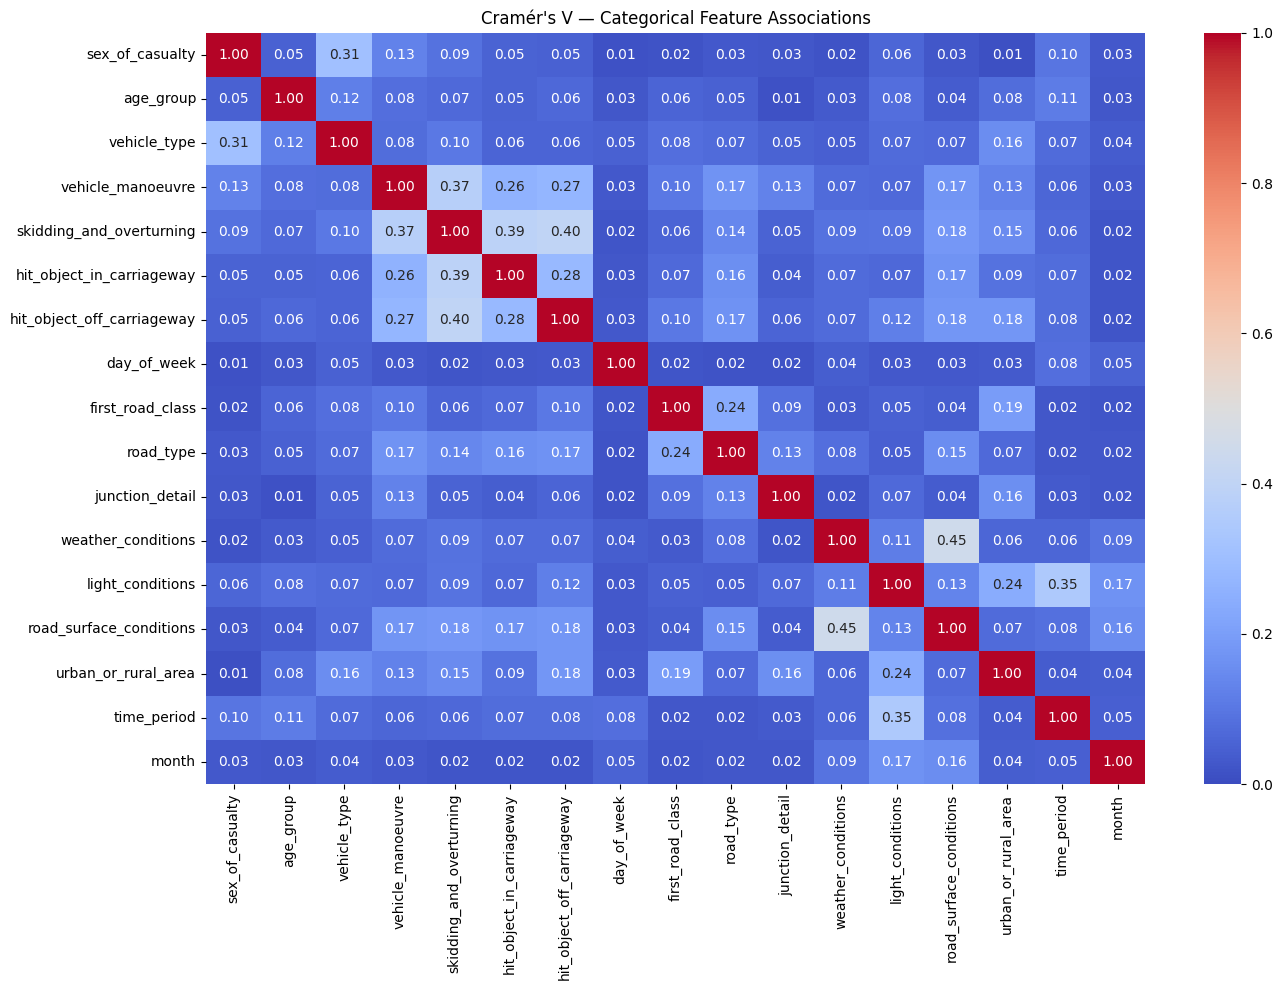

In [62]:
categorical_cols = [
    'sex_of_casualty','age_group','vehicle_type', 'vehicle_manoeuvre',
    'skidding_and_overturning','hit_object_in_carriageway', 'hit_object_off_carriageway',
    'day_of_week','first_road_class','road_type', 'junction_detail', 'weather_conditions',
    'light_conditions','road_surface_conditions',
    'urban_or_rural_area', 'time_period',  'month'
]
numeric_cols = ['speed_limit', 'number_of_vehicles']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

n = len(categorical_cols)
cramers_matrix = pd.DataFrame(np.zeros((n, n)), index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

plt.figure(figsize=(14, 10))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér's V — Categorical Feature Associations")
plt.tight_layout()
plt.show()

###**PEARSON CORRELATION**

In [63]:
pearson_corr = X_train[numeric_cols].corr()
print("Pearson correlation:")
print(pearson_corr)

Pearson correlation:
                    speed_limit  number_of_vehicles
speed_limit            1.000000            0.124885
number_of_vehicles     0.124885            1.000000


####**Road Type vs Collision**

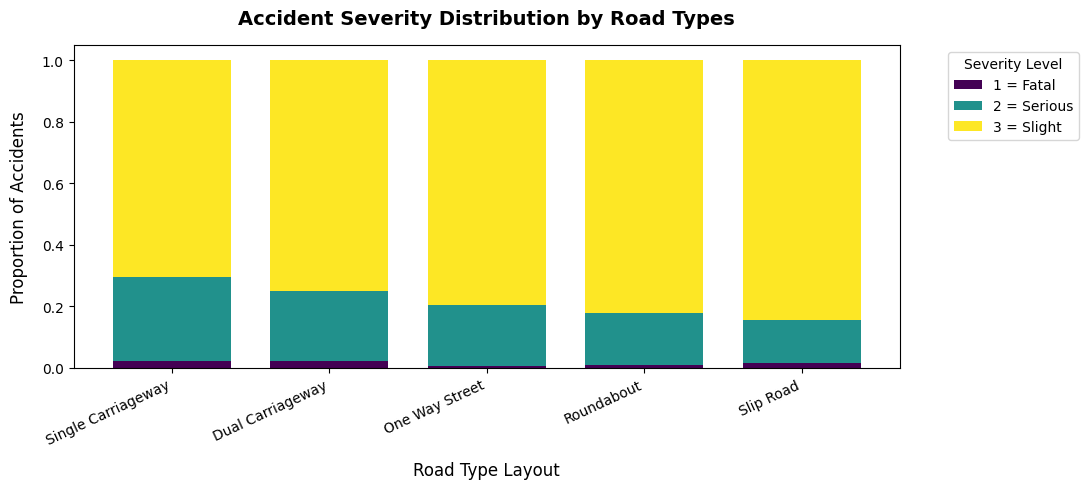

In [65]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

road_type_mapping = {
    1: 'Roundabout',
    2: 'One Way Street',
    3: 'Dual Carriageway',
    6: 'Single Carriageway',
    7: 'Slip Road'
}
plot_df_road = plot_df.copy()
plot_df_road['road_type'] = plot_df_road['road_type'].map(road_type_mapping)

crosstab_df = pd.crosstab(plot_df_road['road_type'], plot_df_road['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop[1] + crosstab_prop[2]
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=False).drop(columns=['severe_ratio'])

ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(11, 5), colormap='viridis', width=0.75)
plt.title('Accident Severity Distribution by Road Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Road Type Layout', fontsize=12, labelpad=10)
plt.ylabel('Proportion of Accidents', fontsize=12, labelpad=10)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

####**Speed Limit vs Collision**

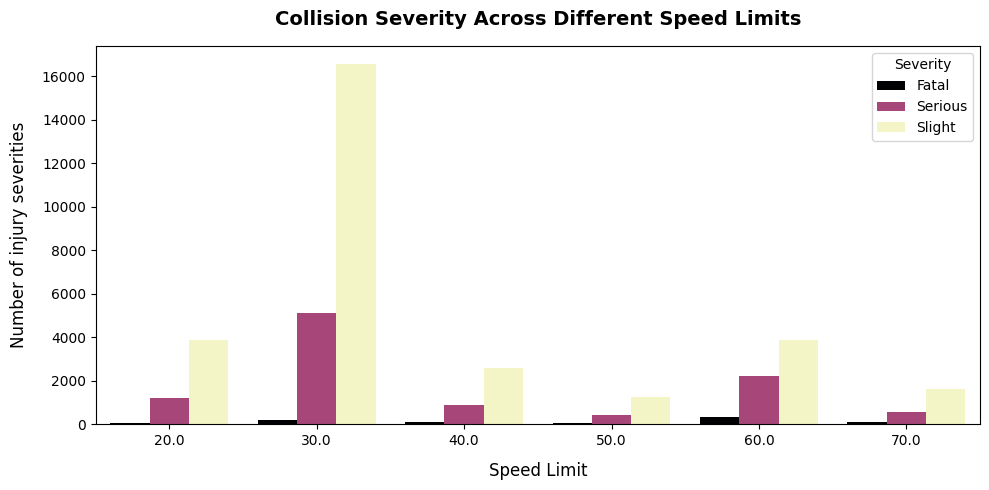

In [66]:
plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x='speed_limit', hue='collision_severity', palette='magma')
plt.title('Collision Severity Across Different Speed Limits', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Speed Limit', fontsize=12, labelpad=10)
plt.ylabel('Number of injury severities', fontsize=12, labelpad=10)
plt.legend(title='Severity', labels=['Fatal', 'Serious', 'Slight'])
plt.tight_layout()
plt.show()

####**Area vs Accident Severity**

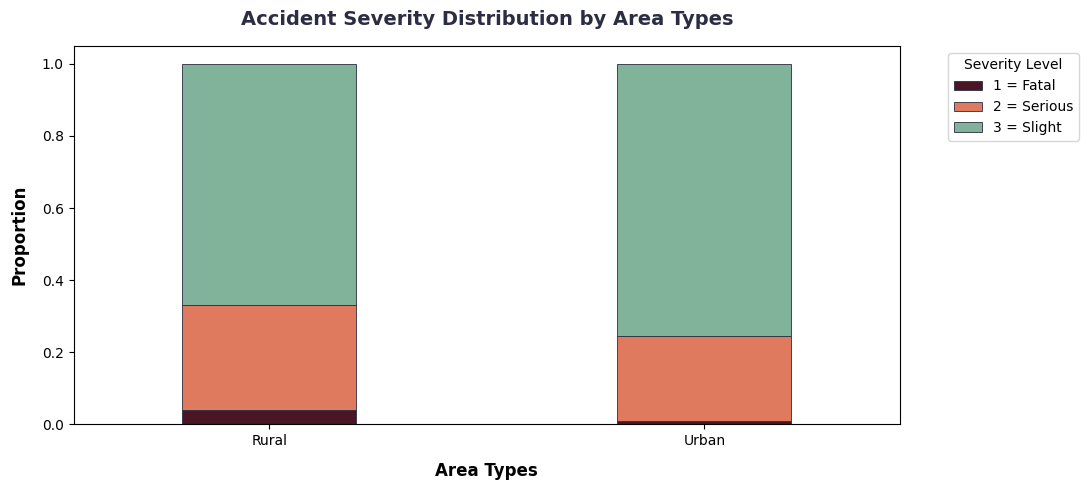

In [67]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

urban_rural_mapping = {
    1: 'Urban',
    2: 'Rural'
}
plot_df['urban_or_rural_area'] = plot_df['urban_or_rural_area'].map(urban_rural_mapping)

crosstab_df = pd.crosstab(plot_df['urban_or_rural_area'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']
ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(11, 5), color=custom_colors, width=0.4, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Area Types', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Area Types', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Proportion', fontsize=12, labelpad=10, fontweight='semibold')

plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

####**number of vehicles vs Accident Severity**

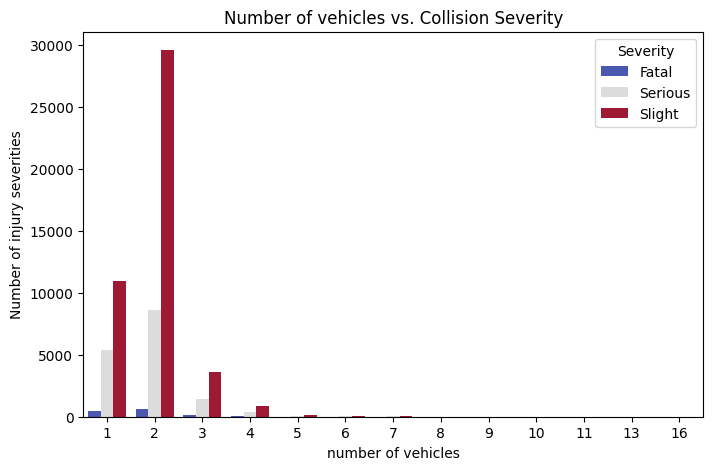

In [68]:
plt.figure(figsize=(8, 5))
sns.countplot(data=merged_df, x='number_of_vehicles', hue='collision_severity', palette='coolwarm')
plt.title('Number of vehicles vs. Collision Severity')
plt.xlabel('number of vehicles')
plt.ylabel('Number of injury severities')
plt.legend(title='Severity', labels=['Fatal', 'Serious', 'Slight'])
plt.show()

####**Weather Conditions vs Accident Severity**

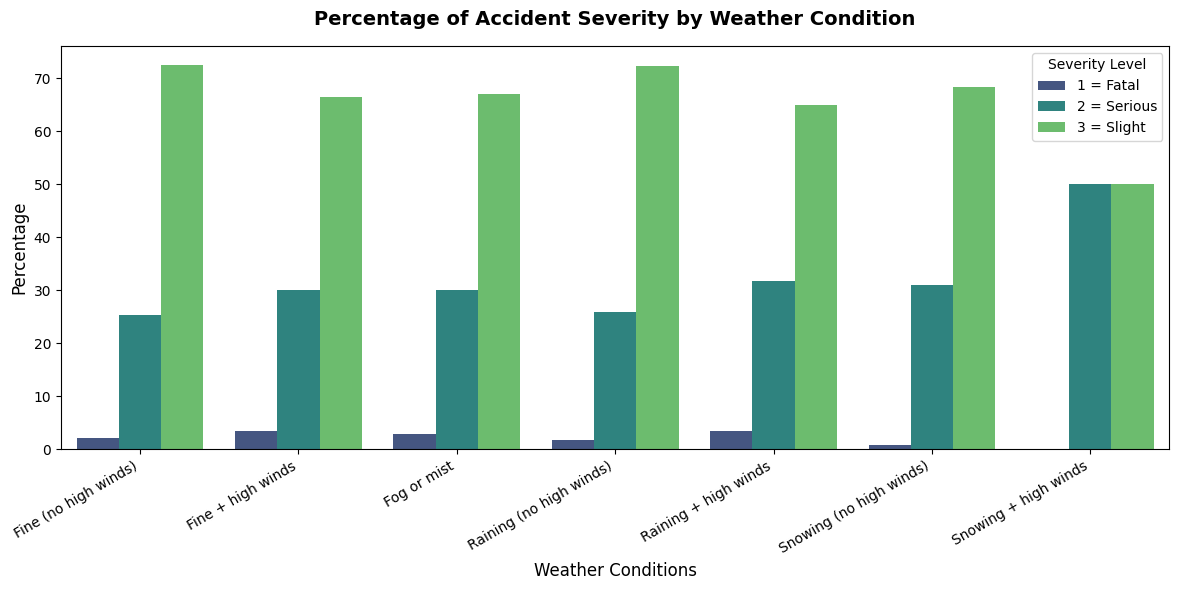

In [69]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

weather_mapping = {
    1: 'Fine (no high winds)',
    2: 'Raining (no high winds)',
    3: 'Snowing (no high winds)',
    4: 'Fine + high winds',
    5: 'Raining + high winds',
    6: 'Snowing + high winds',
    7: 'Fog or mist'
}
plot_df['weather_conditions'] = plot_df['weather_conditions'].map(weather_mapping)

weather_cross = pd.crosstab(plot_df['weather_conditions'], plot_df['collision_severity'], normalize='index') * 100

weather_cross_flat = weather_cross.reset_index().melt(id_vars='weather_conditions', value_name='Percentage')
weather_cross_flat.columns = ['Weather Conditions', 'Severity Level', 'Percentage of Accidents']

weather_cross_flat['Severity Level'] = weather_cross_flat['Severity Level'].map({1: '1 = Fatal', 2: '2 = Serious', 3: '3 = Slight'})

plt.figure(figsize=(12, 6))
sns.barplot(data=weather_cross_flat, x='Weather Conditions', y='Percentage of Accidents', hue='Severity Level', palette='viridis')

plt.title('Percentage of Accident Severity by Weather Condition', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Percentage', fontsize=12)
plt.xlabel('Weather Conditions', fontsize=12)
plt.legend(title='Severity Level', loc='upper right')
plt.tight_layout()
plt.show()

####**Light Conditions vs Accident Severity**

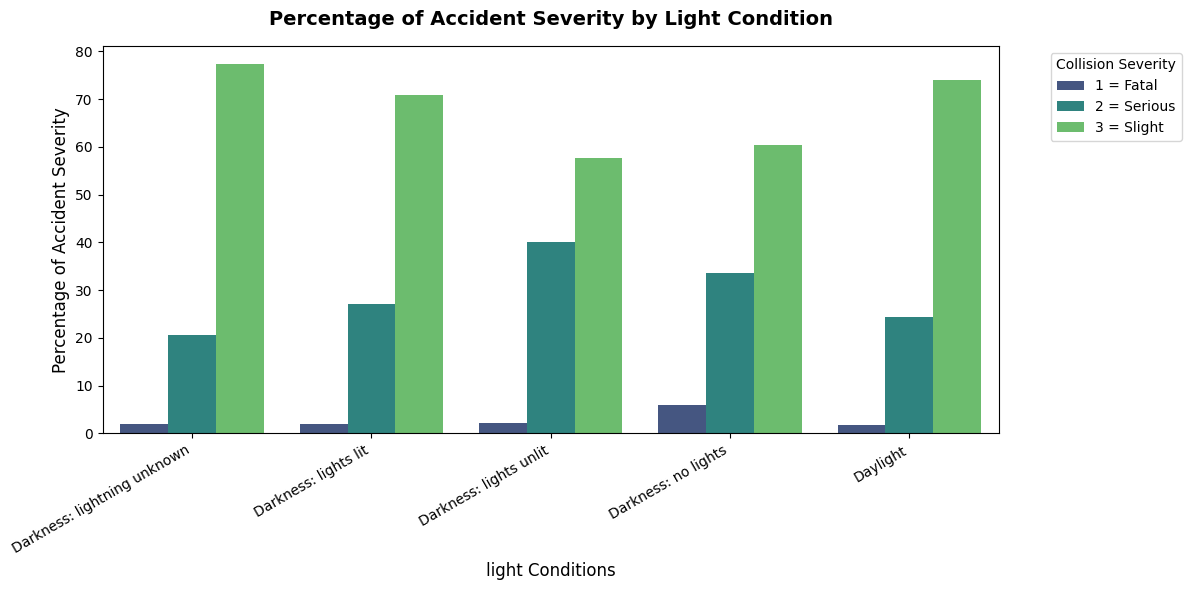

In [70]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

light_mapping = {
    1: 'Daylight',
    4: 'Darkness: lights lit',
    5: 'Darkness: lights unlit',
    6: 'Darkness: no lights',
    7: 'Darkness: lightning unknown'
}

plot_df['light_conditions'] = plot_df['light_conditions'].map(light_mapping)

light_cross = pd.crosstab(plot_df['light_conditions'], plot_df['collision_severity'], normalize='index') * 100

light_cross_flat = light_cross.reset_index().melt(id_vars='light_conditions', value_name='Percentage')
light_cross_flat.columns = ['light Conditions', 'Severity Level', 'Percentage of Accidents']

light_cross_flat['Severity Level'] = light_cross_flat['Severity Level'].map({1: '1 = Fatal', 2: '2 = Serious', 3: '3 = Slight'})

plt.figure(figsize=(12, 6))
sns.barplot(data=light_cross_flat, x='light Conditions', y='Percentage of Accidents', hue='Severity Level', palette='viridis')

plt.title('Percentage of Accident Severity by Light Condition', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Percentage of Accident Severity', fontsize=12)
plt.xlabel('light Conditions', fontsize=12)
plt.legend(title='Collision Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

####**Gender vs Accident Severity**

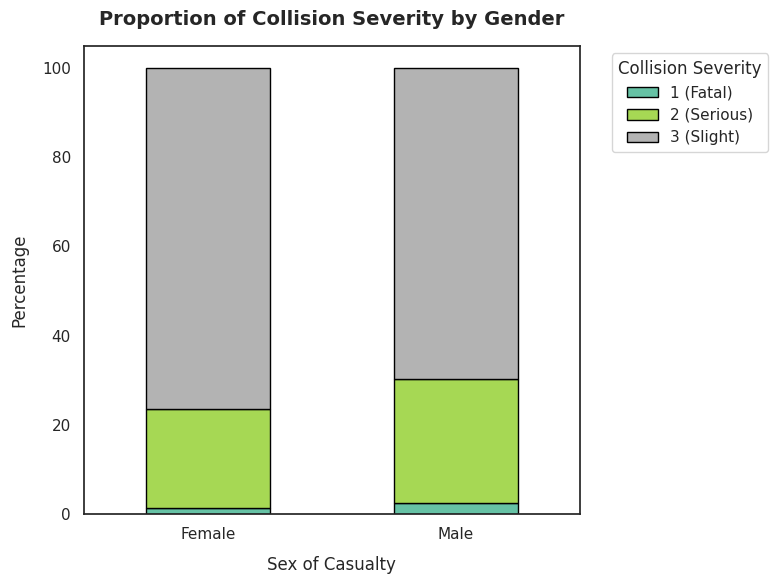

In [71]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

sex_map = {1: 'Male', 2: 'Female'}
severity_map = {1: '1 (Fatal)', 2: '2 (Serious)', 3: '3 (Slight)'}

plot_df['Sex'] = plot_df['sex_of_casualty'].map(sex_map)
plot_df['Severity'] = plot_df['collision_severity'].map(severity_map)

crosstab_prop = pd.crosstab(index=plot_df['Sex'],
                             columns=plot_df['Severity'],
                             normalize='index') * 100

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 6))

crosstab_prop.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    edgecolor='black',
    ax=ax
)

ax.set_title('Proportion of Collision Severity by Gender', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sex of Casualty', fontsize=12, labelpad=10)
ax.set_ylabel('Percentage', fontsize=12, labelpad=10)
plt.xticks(rotation=0)

ax.legend(title='Collision Severity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

####**Time vs CS**

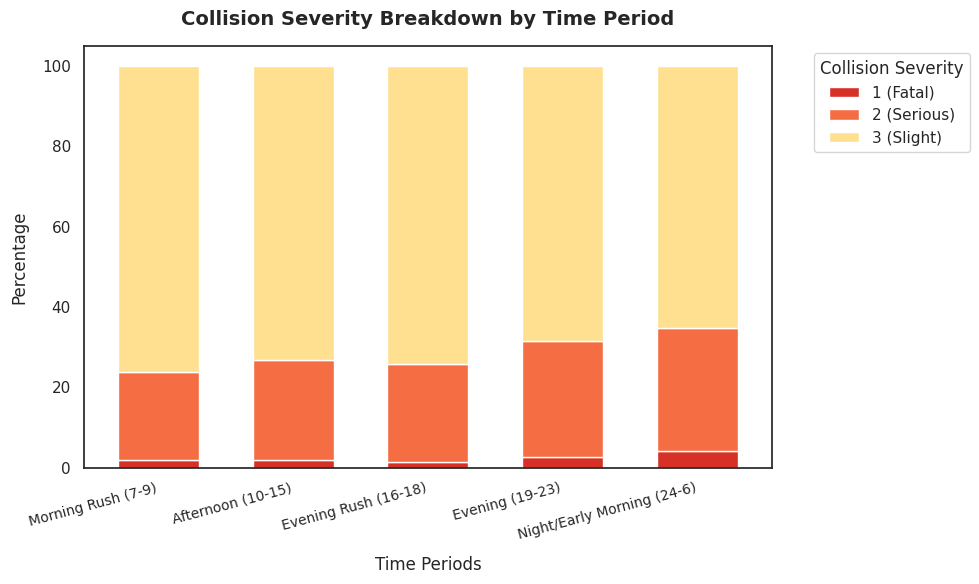

In [72]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

time_labels = {
    1: 'Morning Rush (7-9)',
    2: 'Afternoon (10-15)',
    3: 'Evening Rush (16-18)',
    4: 'Evening (19-23)',
    5: 'Night/Early Morning (24-6)'
}

severity_map = {1: '1 (Fatal)', 2: '2 (Serious)', 3: '3 (Slight)'}

plot_df['time_period_name'] = plot_df['time_period'].map(time_labels)
plot_df['collision_severity_name'] = plot_df['collision_severity'].map(severity_map)

ct = pd.crosstab(plot_df['time_period_name'], plot_df['collision_severity_name'], normalize='index') * 100

time_order = [time_labels[i] for i in [1, 2, 3, 4, 5]]
severity_order = [severity_map[i] for i in [1, 2, 3]]

ct = ct.reindex(index=time_order, columns=severity_order)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d73027', '#f46d43', '#fee090']

ct.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.6)

plt.title('Collision Severity Breakdown by Time Period', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time Periods', fontsize=12, labelpad=10)
plt.ylabel('Percentage', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right', fontsize=10)
plt.legend(title='Collision Severity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

####**Day vs CS**

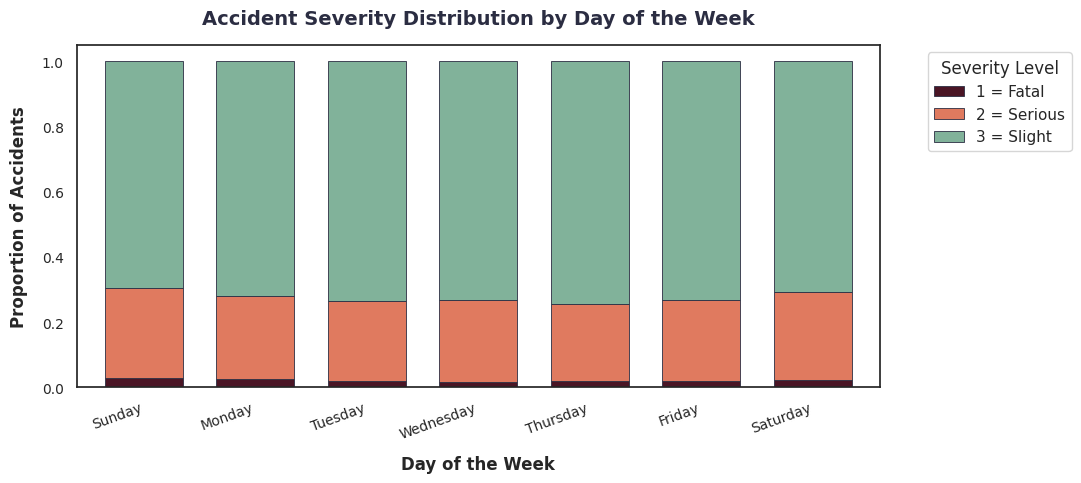

In [ ]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

day_mapping = {
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}
plot_df['day_of_week'] = plot_df['day_of_week'].map(day_mapping)

crosstab_df = pd.crosstab(plot_df['day_of_week'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

calendar_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
crosstab_prop = crosstab_prop.reindex(calendar_order)

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(11, 5), color=custom_colors, width=0.7, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Day of the Week', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Day of the Week', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')

plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Road Surface Conditions vs CS**

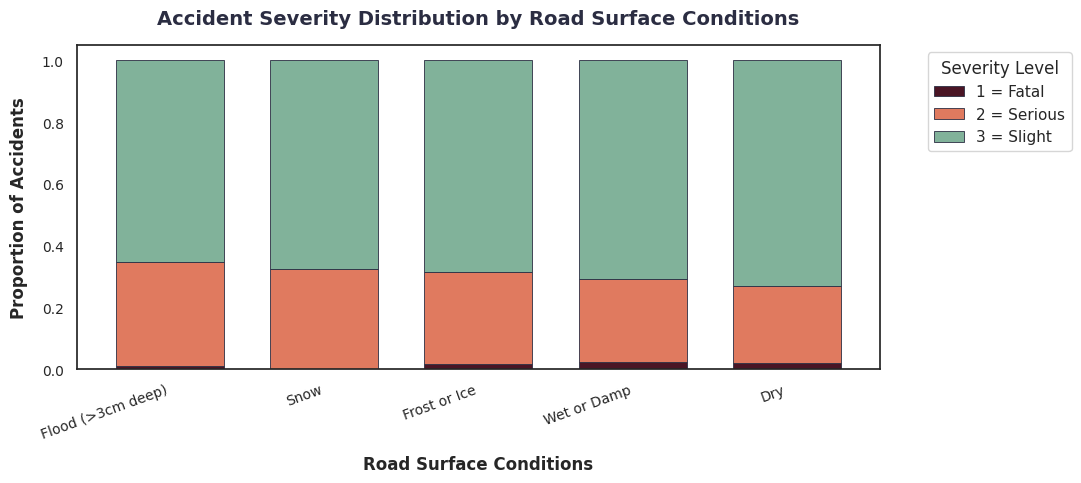

In [73]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

surface_mapping = {
    1: 'Dry',
    2: 'Wet or Damp',
    3: 'Snow',
    4: 'Frost or Ice',
    5: 'Flood (>3cm deep)',
    6: 'Oil or diesel',
    7: 'Mud'
}
plot_df['road_surface_conditions'] = plot_df['road_surface_conditions'].map(surface_mapping)

crosstab_df = pd.crosstab(plot_df['road_surface_conditions'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop[1] + crosstab_prop[2]
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=False).drop(columns=['severe_ratio'])

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='bar', stacked=True, figsize=(11, 5), color=custom_colors, width=0.7, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Road Surface Conditions', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Road Surface Conditions', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')

plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Vehicle Type vs CS**

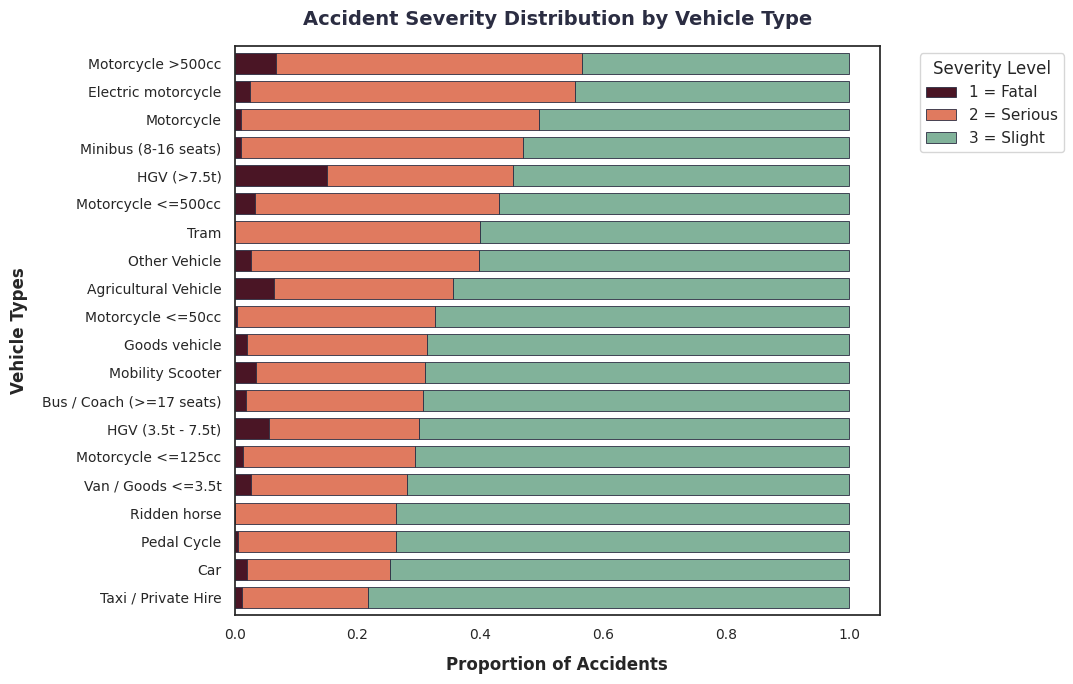

In [74]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

vehicle_mapping = {
    1: 'Pedal Cycle',
    2: 'Motorcycle <=50cc',
    3: 'Motorcycle <=125cc',
    4: 'Motorcycle <=500cc',
    5: 'Motorcycle >500cc',
    8: 'Taxi / Private Hire',
    9: 'Car',
    10: 'Minibus (8-16 seats)',
    11: 'Bus / Coach (>=17 seats)',
    16: 'Ridden horse',
    17: 'Agricultural Vehicle',
    18: 'Tram',
    19: 'Van / Goods <=3.5t',
    20: 'HGV (3.5t - 7.5t)',
    21: 'HGV (>7.5t)',
    22: 'Mobility Scooter',
    23: 'Electric motorcycle',
    90: 'Other Vehicle',
    97: 'Motorcycle',
    98: 'Goods vehicle',
    103: 'Motorcycle-Scooter',
    106: 'Motorcycle over 125cc'
}
plot_df['vehicle_type'] = plot_df['vehicle_type'].map(vehicle_mapping)

plot_df = plot_df.dropna(subset=['vehicle_type'])
crosstab_df = pd.crosstab(plot_df['vehicle_type'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop.get(1, 0) + crosstab_prop.get(2, 0)
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=True).drop(columns=['severe_ratio'])

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='barh', stacked=True, figsize=(11, 7), color=custom_colors, width=0.75, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Vehicle Type', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Vehicle Types', fontsize=12, labelpad=10, fontweight='semibold')

plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Skidding and Overturning vs CS**

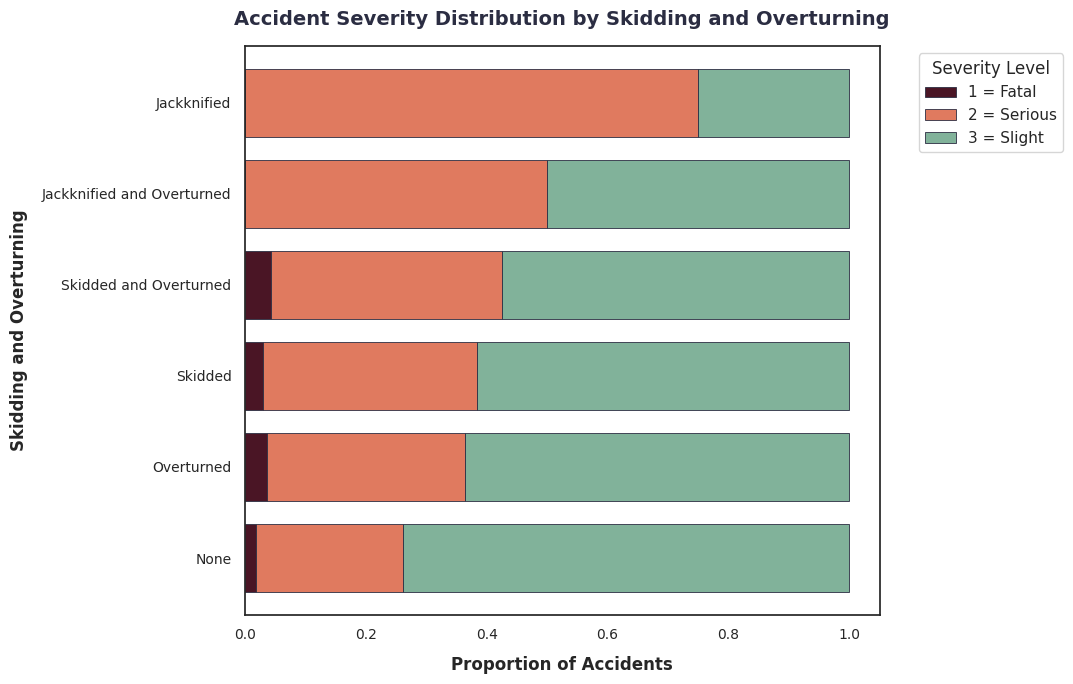

In [75]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

skidding_mapping = {
    0: 'None',
    1: 'Skidded',
    2: 'Skidded and Overturned',
    3: 'Jackknified',
    4: 'Jackknified and Overturned',
    5: 'Overturned'
}
plot_df['skidding_and_overturning'] = plot_df['skidding_and_overturning'].map(skidding_mapping)

plot_df = plot_df.dropna(subset=['skidding_and_overturning'])

crosstab_df = pd.crosstab(plot_df['skidding_and_overturning'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop[1] + crosstab_prop[2]
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=True).drop(columns=['severe_ratio'])

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='barh', stacked=True, figsize=(11, 7), color=custom_colors, width=0.75, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Skidding and Overturning', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Skidding and Overturning', fontsize=12, labelpad=10, fontweight='semibold')

plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Hit obj in carriage way vs CS**

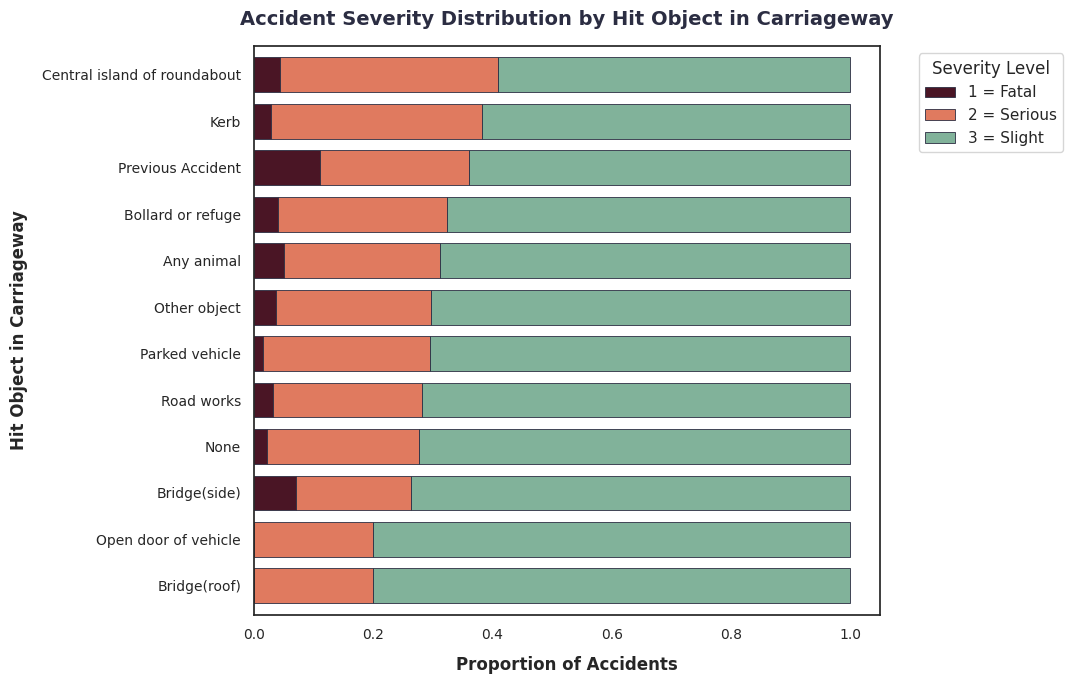

In [76]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

hit_in_mapping = {
    0: 'None',
    1: 'Previous Accident',
    2: 'Road works',
    4: 'Parked vehicle',
    5: 'Bridge(roof)',
    6: 'Bridge(side)',
    7: 'Bollard or refuge',
    8: 'Open door of vehicle',
    9: 'Central island of roundabout',
    10: 'Kerb',
    11: 'Other object',
    12: 'Any animal'
}
plot_df['hit_object_in_carriageway'] = plot_df['hit_object_in_carriageway'].map(hit_in_mapping)

plot_df = plot_df.dropna(subset=['hit_object_in_carriageway'])

crosstab_df = pd.crosstab(plot_df['hit_object_in_carriageway'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop[1] + crosstab_prop[2]
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=True).drop(columns=['severe_ratio'])

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='barh', stacked=True, figsize=(11, 7), color=custom_colors, width=0.75, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Hit Object in Carriageway', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Hit Object in Carriageway', fontsize=12, labelpad=10, fontweight='semibold')

plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Hit obj off carriage way vs CS**

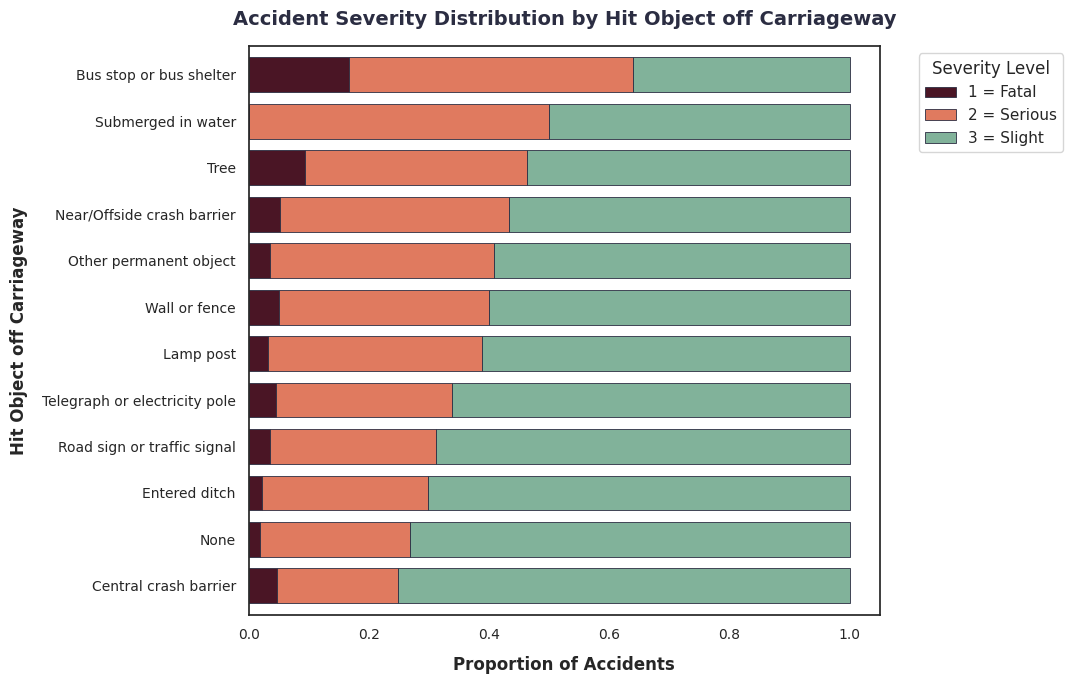

In [77]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

hit_off_mapping = {
    0: 'None',
    1: 'Road sign or traffic signal',
    2: 'Lamp post',
    3: 'Telegraph or electricity pole',
    4: 'Tree',
    5: 'Bus stop or bus shelter',
    6: 'Central crash barrier',
    7: 'Near/Offside crash barrier',
    8: 'Submerged in water',
    9: 'Entered ditch',
    10: 'Other permanent object',
    11: 'Wall or fence'
}
plot_df['hit_object_off_carriageway'] = plot_df['hit_object_off_carriageway'].map(hit_off_mapping)

crosstab_df = pd.crosstab(plot_df['hit_object_off_carriageway'], plot_df['collision_severity'])
crosstab_prop = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)

crosstab_prop['severe_ratio'] = crosstab_prop[1] + crosstab_prop[2]
crosstab_prop = crosstab_prop.sort_values(by='severe_ratio', ascending=True).drop(columns=['severe_ratio'])

custom_colors = ['#4a1525', '#e07a5f', '#81b29a']

ax = crosstab_prop.plot(kind='barh', stacked=True, figsize=(11, 7), color=custom_colors, width=0.75, edgecolor='#2b2d42', linewidth=0.6)

plt.title('Accident Severity Distribution by Hit Object off Carriageway', fontsize=14, fontweight='bold', pad=15, color='#2b2d42')
plt.xlabel('Proportion of Accidents', fontsize=12, labelpad=10, fontweight='semibold')
plt.ylabel('Hit Object off Carriageway', fontsize=12, labelpad=10, fontweight='semibold')

plt.xlim(0, 1.05)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Severity Level', labels=['1 = Fatal', '2 = Serious', '3 = Slight'],
           loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**Junction Detail vs CS**

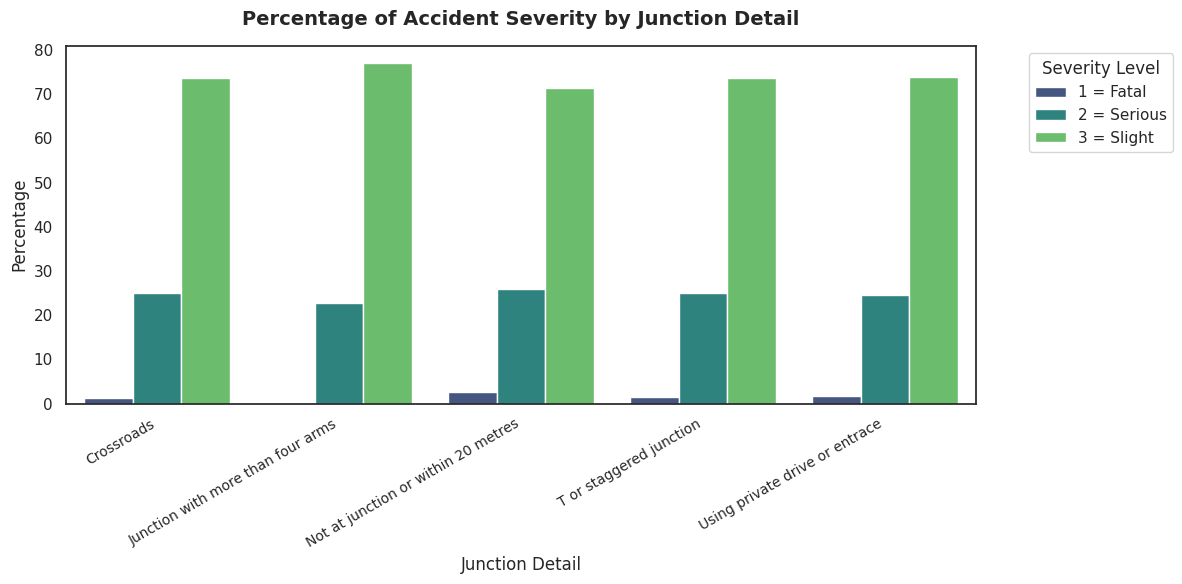

In [79]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

junction_mapping = {
    0: 'Not at junction or within 20 metres',
    13: 'T or staggered junction',
    16: 'Crossroads',
    17: 'Junction with more than four arms',
    18: 'Using private drive or entrace'
}

plot_df['junction_detail'] = plot_df['junction_detail'].map(junction_mapping)

junction_detail = pd.crosstab(plot_df['junction_detail'], plot_df['collision_severity'], normalize='index') * 100

junction_detail_flat = junction_detail.reset_index().melt(id_vars='junction_detail', value_name='Percentage')
junction_detail_flat.columns = ['Junction Detail', 'Severity Level', 'Percentage of Accidents']

junction_detail_flat['Severity Level'] = junction_detail_flat['Severity Level'].map({1: '1 = Fatal', 2: '2 = Serious', 3: '3 = Slight'})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=junction_detail_flat,
    x='Junction Detail',
    y='Percentage of Accidents',
    hue='Severity Level',
    hue_order=['1 = Fatal', '2 = Serious', '3 = Slight'],
    palette='viridis'
)


plt.title('Percentage of Accident Severity by Junction Detail', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Percentage', fontsize=12)
plt.xlabel('Junction Detail', fontsize=12)

plt.legend(title='Severity Level', loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**First Road Class vs CS**

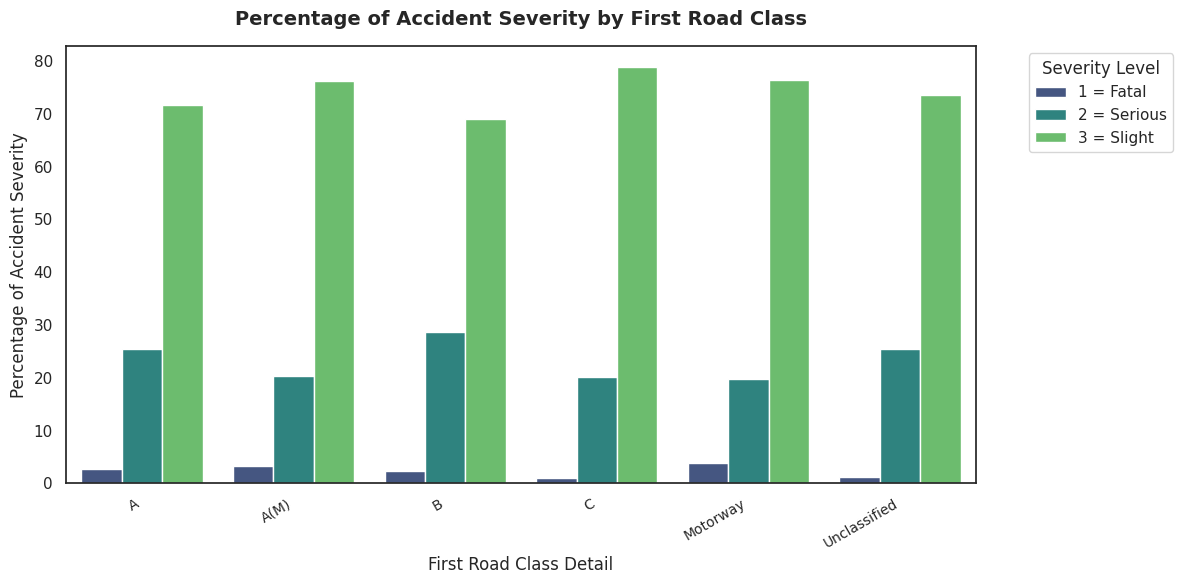

In [80]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

first_road_mapping = {
    1: 'Motorway',
    2: 'A(M)',
    3: 'A',
    4: 'B',
    5: 'C',
    6: 'Unclassified'
}

plot_df['first_road_class'] = plot_df['first_road_class'].map(first_road_mapping)

first_road_class = pd.crosstab(plot_df['first_road_class'], plot_df['collision_severity'], normalize='index') * 100

first_road_class_flat = first_road_class.reset_index().melt(id_vars='first_road_class', value_name='Percentage')
first_road_class_flat.columns = ['First Road Class Detail', 'Severity Level', 'Percentage of Accidents']

first_road_class_flat['Severity Level'] = first_road_class_flat['Severity Level'].map({1: '1 = Fatal', 2: '2 = Serious', 3: '3 = Slight'})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=first_road_class_flat,
    x='First Road Class Detail',
    y='Percentage of Accidents',
    hue='Severity Level',
    hue_order=['1 = Fatal', '2 = Serious', '3 = Slight'],
    palette='viridis'
)

plt.title('Percentage of Accident Severity by First Road Class', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Percentage of Accident Severity', fontsize=12)
plt.xlabel('First Road Class Detail', fontsize=12)

plt.legend(title='Severity Level', loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

###**Age Group vs Collision Severity**

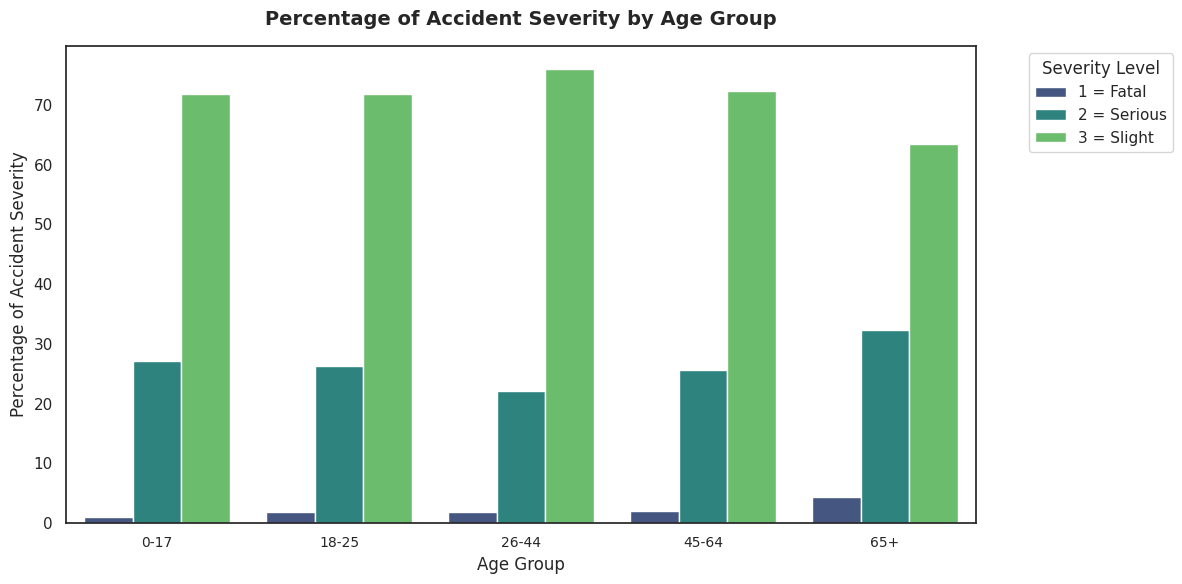

In [81]:
plot_df = X_train.copy()
plot_df['collision_severity'] = y_train.values

age_group_mapping = {
    1: '0-17',
    2: '18-25',
    3: '26-44',
    4: '45-64',
    5: '65+'
}

plot_df['age_group'] = plot_df['age_group'].map(age_group_mapping)

age_group_ct = pd.crosstab(plot_df['age_group'], plot_df['collision_severity'], normalize='index') * 100

age_group_flat = age_group_ct.reset_index().melt(id_vars='age_group', value_name='Percentage')
age_group_flat.columns = ['Age Group', 'Severity Level', 'Percentage of Accidents']

age_group_flat['Severity Level'] = age_group_flat['Severity Level'].map({1: '1 = Fatal', 2: '2 = Serious', 3: '3 = Slight'})

plt.figure(figsize=(12, 6))

sns.barplot(
    data=age_group_flat,
    x='Age Group',
    y='Percentage of Accidents',
    hue='Severity Level',
    hue_order=['1 = Fatal', '2 = Serious', '3 = Slight'],
    order=['0-17', '18-25', '26-44', '45-64', '65+'],
    palette='viridis'
)

plt.title('Percentage of Accident Severity by Age Group', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0, ha='center', fontsize=10)
plt.ylabel('Percentage of Accident Severity', fontsize=12)
plt.xlabel('Age Group', fontsize=12)

plt.legend(title='Severity Level', loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

####**SMOTE-NC**

In [82]:
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)

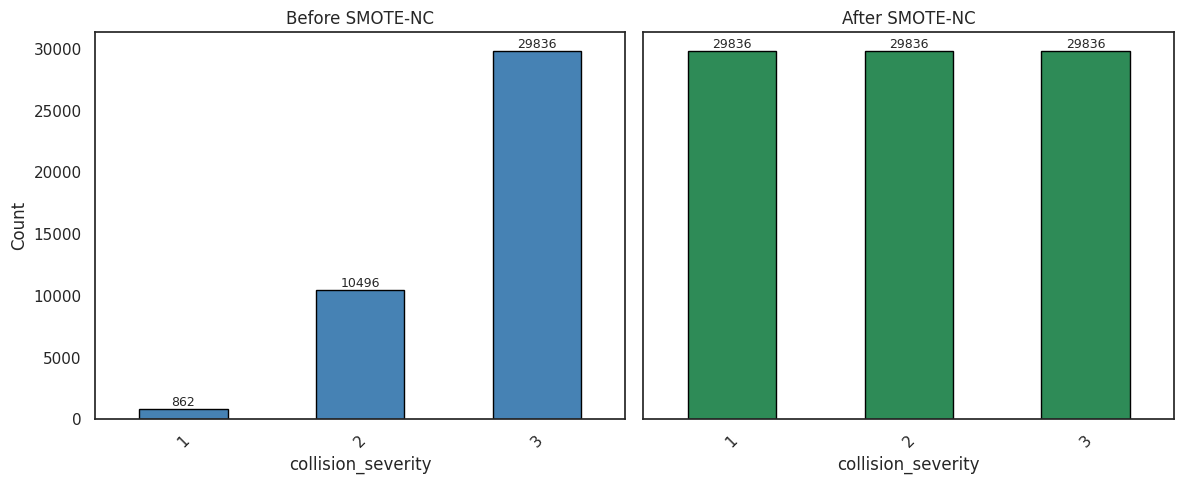

In [83]:
before_counts = y_train.value_counts().sort_index()
X_resampled, y_resampled = smotenc.fit_resample(X_train, y_train)
after_counts = y_resampled.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

before_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Before SMOTE-NC')
axes[0].set_xlabel('collision_severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(before_counts):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

after_counts.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('After SMOTE-NC')
axes[1].set_xlabel('collision_severity')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(after_counts):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [84]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_cols),
        ("categorical", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [85]:
log_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        ("categorical", OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [86]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

####**Ordinal Logistic Regression**

In [ ]:
!pip install mord --quiet

  Preparing metadata (setup.py) ... done


In [ ]:
from mord import LogisticAT
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

log_pipeline = Pipeline(steps=[
    ("smotenc", smotenc),
    ("preprocessor", log_preprocessor),
    ("model", LogisticAT())
])

log_pipeline.fit(X_train, y_train)
log_pred_test = log_pipeline.predict(X_test)

In [ ]:
print("Ordinal Logistic Regression")

print("\nClassification Report:")
print(classification_report(y_test, log_pred_test, target_names=['Fatal', 'Serious', 'Slight']))

Ordinal Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.07      0.26      0.11       369
     Serious       0.29      0.49      0.36      4498
      Slight       0.78      0.53      0.63     12788

    accuracy                           0.51     17655
   macro avg       0.38      0.43      0.37     17655
weighted avg       0.64      0.51      0.55     17655



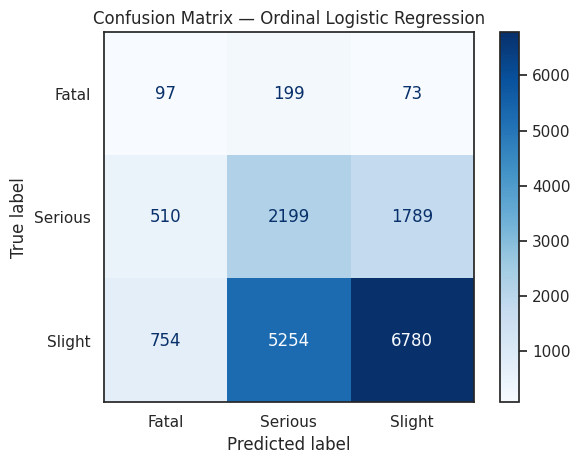

In [ ]:
cm = confusion_matrix(y_test, log_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fatal', 'Serious', 'Slight'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Ordinal Logistic Regression')
plt.tight_layout()
plt.show()

###**Random Forest**

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("smotenc", smotenc),
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}


rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.predict(X_test)

print("Best Parameters (RF):")
print(rf_grid.best_params_)


print(classification_report(y_test, rf_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters (RF):
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
              precision    recall  f1-score   support

           1       0.33      0.24      0.28       369
           2       0.47      0.42      0.45      4498
           3       0.80      0.84      0.82     12788

    accuracy                           0.72     17655
   macro avg       0.54      0.50      0.51     17655
weighted avg       0.71      0.72      0.71     17655



In [ ]:
print("Best Parameters (RF):")
print(rf_grid.best_params_)


print(classification_report(y_test, rf_pred, target_names=['Fatal', 'Serious', 'Slight']))

Best Parameters (RF):
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
              precision    recall  f1-score   support

       Fatal       0.33      0.24      0.28       369
     Serious       0.47      0.42      0.45      4498
      Slight       0.80      0.84      0.82     12788

    accuracy                           0.72     17655
   macro avg       0.54      0.50      0.51     17655
weighted avg       0.71      0.72      0.71     17655



####**CONFUSION MATRIX — Random Forest**

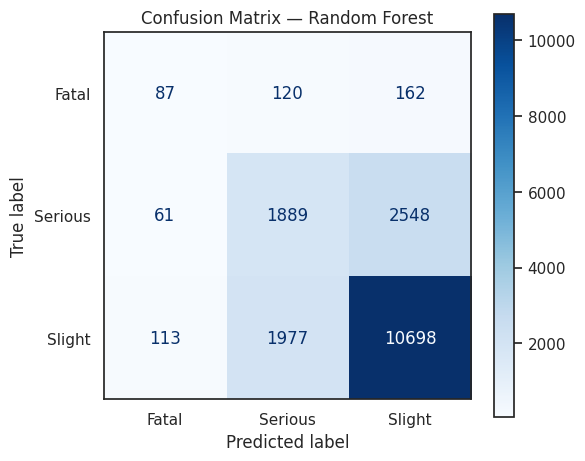

In [ ]:
cm = confusion_matrix(y_test, rf_pred, labels=rf_grid.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fatal', 'Serious', 'Slight'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

###**Decision Tree**

In [ ]:
dt_pipeline = Pipeline(steps=[
    ("smotenc", smotenc),
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipeline, dt_params, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=2
)
dt_grid.fit(X_train, y_train)

print("Best Parameters (DT):")
print(dt_grid.best_params_)

dt_pred = dt_grid.predict(X_test)
print(classification_report(y_test, dt_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters (DT):
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_split': 2}
              precision    recall  f1-score   support

           1       0.18      0.31      0.23       369
           2       0.36      0.46      0.41      4498
           3       0.79      0.70      0.74     12788

    accuracy                           0.63     17655
   macro avg       0.44      0.49      0.46     17655
weighted avg       0.67      0.63      0.65     17655



In [ ]:
print("Best Parameters (DT):")
print(dt_grid.best_params_)

print(classification_report(y_test, dt_pred,target_names=['Fatal', 'Serious', 'Slight']))

Best Parameters (DT):
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_split': 2}
              precision    recall  f1-score   support

       Fatal       0.18      0.31      0.23       369
     Serious       0.36      0.46      0.41      4498
      Slight       0.79      0.70      0.74     12788

    accuracy                           0.63     17655
   macro avg       0.44      0.49      0.46     17655
weighted avg       0.67      0.63      0.65     17655



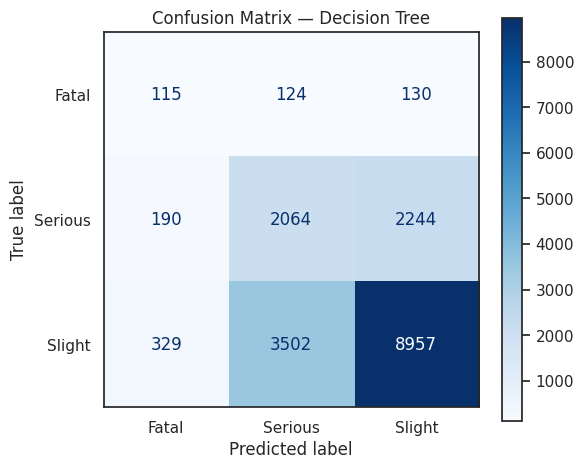

In [ ]:
cm = confusion_matrix(y_test, dt_pred, labels=dt_grid.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fatal', 'Serious', 'Slight'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

###**XGBoost**

In [87]:
xgb_pipeline = Pipeline(
    steps=[
        ("smotenc", smotenc),
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss"))
    ]
)

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train_xgb)

print("Best Parameters (XGBoost):")
print(xgb_grid.best_params_)

xgb_pred = xgb_grid.predict(X_test)

print("Classification Report (XGBoost):")
print(classification_report(y_test_xgb, xgb_pred, target_names=['Fatal', 'Serious', 'Slight']))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters (XGBoost):
{'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200}
Classification Report (XGBoost):
              precision    recall  f1-score   support

       Fatal       0.10      0.36      0.15       369
     Serious       0.36      0.44      0.39      4498
      Slight       0.80      0.68      0.73     12788

    accuracy                           0.61     17655
   macro avg       0.42      0.49      0.43     17655
weighted avg       0.67      0.61      0.63     17655



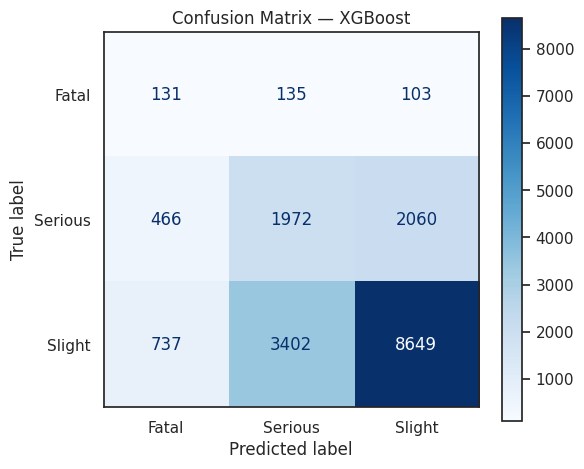

In [ ]:
xgb_pred_original = xgb_pred + 1

cm = confusion_matrix(y_test, xgb_pred_original, labels=[1, 2, 3])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fatal', 'Serious', 'Slight'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

###**XAI**

In [ ]:
import shap

best_rf_pipeline = rf_grid.best_estimator_
preprocessor = best_rf_pipeline.named_steps["preprocessor"]
best_rf_model = best_rf_pipeline.named_steps["model"]

X_shap_sample = X_test.sample(n=200, random_state=42)
X_shap_processed = preprocessor.transform(X_shap_sample)

feature_names = preprocessor.get_feature_names_out()
cleaned_feature_names = [
    col.replace("numeric__", "").replace("categorical__", "")
    for col in feature_names
]
if hasattr(X_shap_processed, "toarray"):
    X_shap_processed_df = pd.DataFrame(X_shap_processed.toarray(), columns=cleaned_feature_names)
else:
    X_shap_processed_df = pd.DataFrame(X_shap_processed, columns=cleaned_feature_names)

explainer = shap.TreeExplainer(best_rf_model)

shap_values = explainer(X_shap_processed_df, check_additivity=False)

###**Global Explanation**

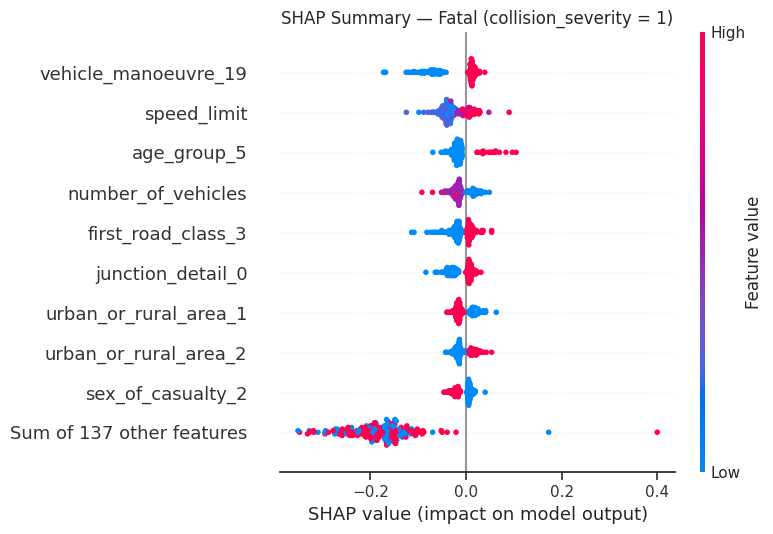

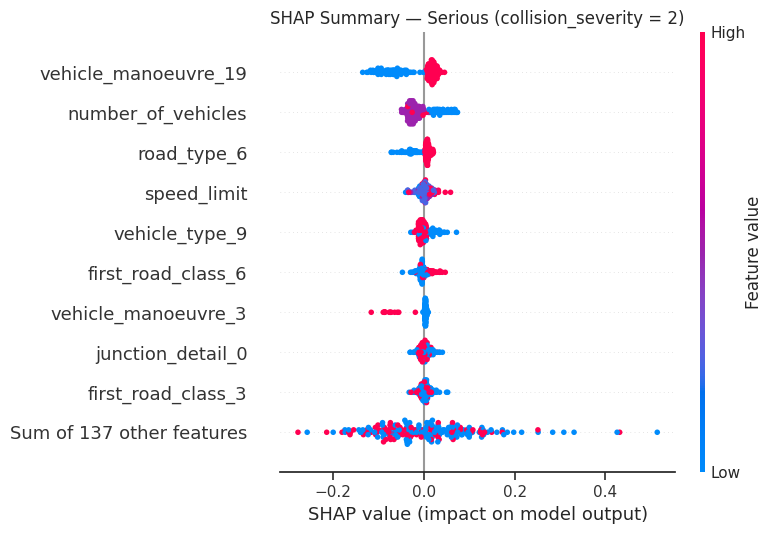

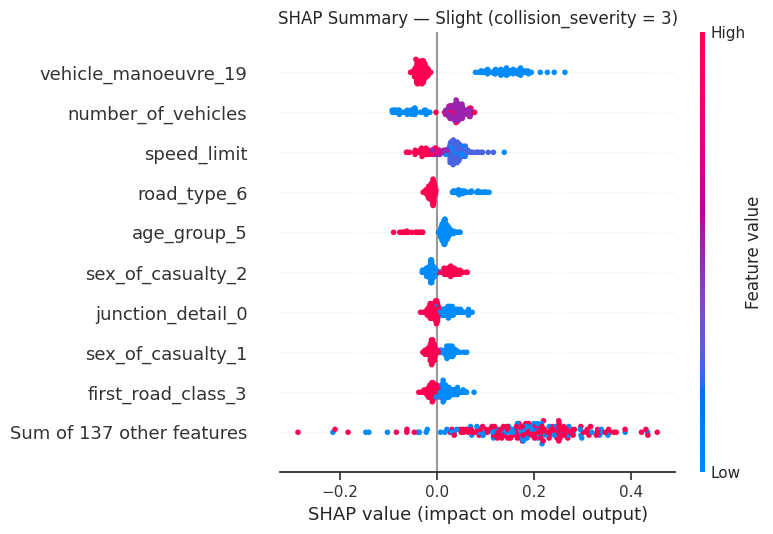

In [ ]:
class_names = {0: 'Fatal', 1: 'Serious', 2: 'Slight'}

for i in range(3):
    shap.plots.beeswarm(shap_values[:, :, i], show=False)
    plt.title(f"SHAP Summary — {class_names[i]} (collision_severity = {i+1})")
    plt.tight_layout()
    plt.show()

###**Local Explanation**

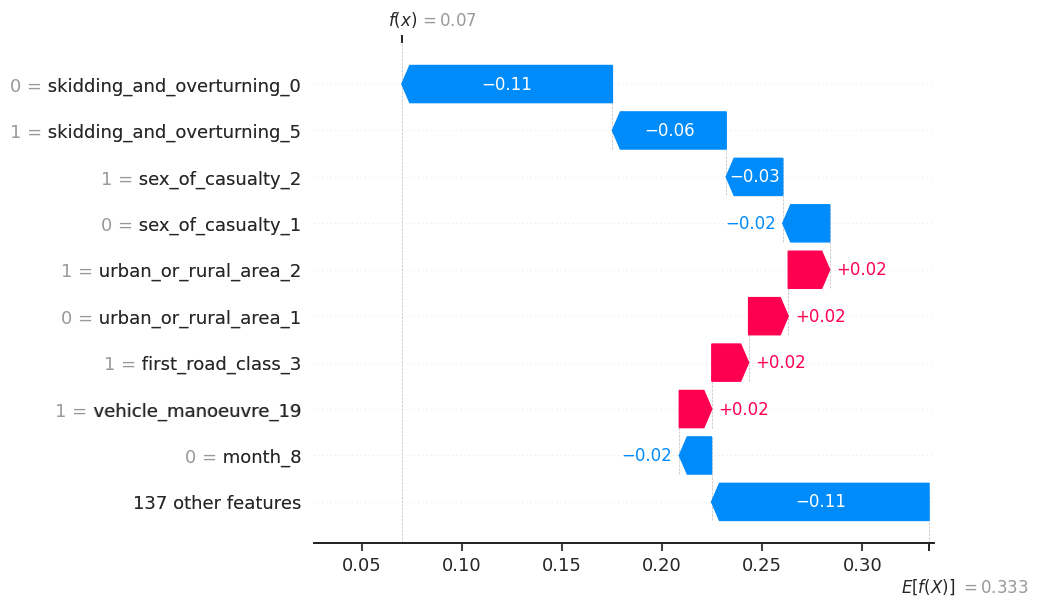

In [ ]:
shap.plots.waterfall(shap_values[0, :, 0])

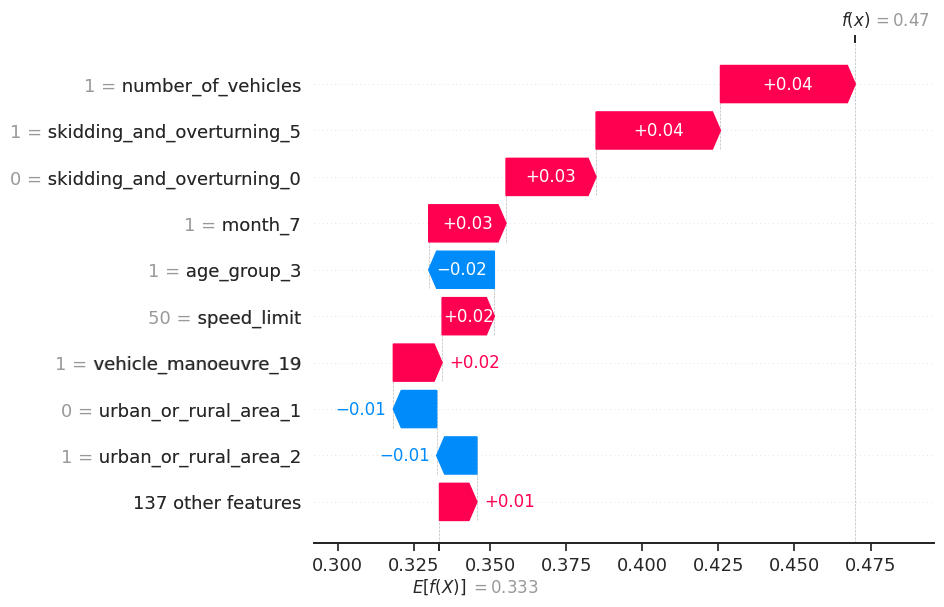

In [ ]:
shap.plots.waterfall(shap_values[0, :, 1])

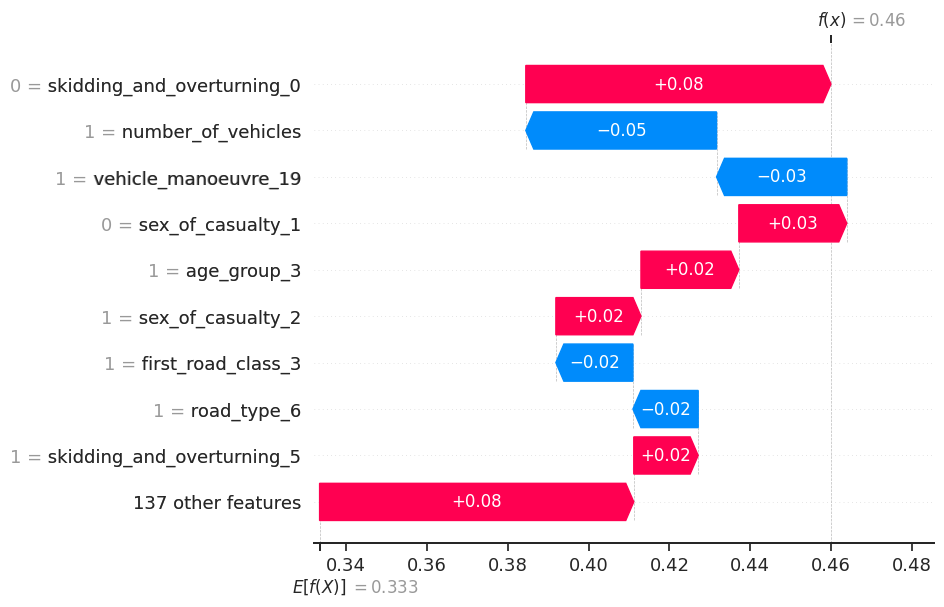

In [ ]:
shap.plots.waterfall(shap_values[0, :, 2])